# Phylogeny of datasets

## Minhash phylogeny - Sourmash

#### Testing

##### making sketches

In [ ]:
import sourmash
seq1 = "ATGGCA"
seq2 = "AGAGCA"

mh1 = sourmash.MinHash(n=0, ksize=3, scaled=1)
mh1.add_sequence(seq1, force=True)

mh2 = sourmash.MinHash(n=0, ksize=3, scaled=1)
mh2.add_sequence(seq2, force=True)

In [ ]:
mh1.jaccard(mh1)

### Phage Minhashing 

##### Constructing signatures using manipulations.py

In [ ]:
import os, sys 
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

from manipulations import construct_SM_sketches
construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/phage_cleaned.fasta", 
                      k = 18, 
                      outdir = "PhageMinhash_n500_k18/", 
                      quiet = False,
                      sourmash_parameters=[500, 0])


##### iterating through kmers

In [ ]:
import sourmash
from Bio import SeqIO
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

records = list(SeqIO.parse(raw_data_path+"phagehost_KU/phage_cleaned.fasta", "fasta"))
K = 8

#only first record
print("First record:", records[0].id, len(records[0].seq))
mh1 = sourmash.MinHash(n=0, ksize=K, scaled=1)
for i in range(0, len(records[0].seq) - K + 1):
    kmer = str(records[0].seq[i:i+K])
    mh1.add_sequence(kmer, force=True)
    print(i, kmer, mh1.seq_to_hashes(kmer))

#second record
print("Second record:", records[1].id, len(records[1].seq))
mh2 = sourmash.MinHash(n=0, ksize=K, scaled=1)
for i in range(0, len(records[1].seq) - K + 1):
    kmer = str(records[1].seq[i:i+K])
    mh2.add_sequence(kmer, force=True)
    print(i, kmer, mh2.seq_to_hashes(kmer))

Comparing sketches of mh1 and mh2

In [ ]:
from tqdm import tqdm

#Constructing minhashes for all records
minhashes = []
for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
    #print("Record:", rec.id, len(rec.seq))
    mh = sourmash.MinHash(n=0, ksize=K, scaled=1) #each record gets its own minhash
    for i in range(0, len(rec.seq) - K + 1):
        kmer = str(rec.seq[i:i+K])
        mh.add_sequence(kmer, force=True)
    minhashes.append(mh)

#Comparing all minhashes
similarity_matrix = dict()
for i, e in enumerate(minhashes):
    sim_inner = dict()
    for j, e2 in enumerate(minhashes):
        x = e.jaccard(minhashes[j])
        sim_inner[records[j].id.split("_")[-1]] = x
    similarity_matrix[records[i].id.split("_")[-1]] = sim_inner

### Converting all phage genomes to sketches and saving

In [ ]:
from tqdm import tqdm
from Bio import SeqIO
import sourmash, sys, os
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"
K = 12 #kmer size in nucleotides 

records = list(SeqIO.parse(raw_data_path+"phagehost_KU/phage_cleaned.fasta", "fasta"))

#Constructing minhashes for all records
minhashes = []
phage_names = []
for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
    #print("Record:", rec.id, len(rec.seq))
    mh = sourmash.MinHash(n=500000, ksize=K, scaled=0) #each record gets its own minhash | scaled=1000 to limit 
    for i in range(0, len(rec.seq) - K + 1):
        kmer = str(rec.seq[i:i+K])
        mh.add_sequence(kmer, force=True)
    minhashes.append(mh)
    phage_names.append(rec.id.split("_")[-1])

if len(minhashes) != len(records):
    print("Warning: Number of minhashes does not match number of records!")
    sys.exit(1)

#Comparing all minhashes
similarity_matrix = dict()
for i, e in enumerate(minhashes):
    sim_inner = dict()
    for j, e2 in enumerate(minhashes):
        x = e.jaccard(minhashes[j])
        sim_inner[records[j].id] = x
    similarity_matrix[records[i].id] = sim_inner

#Creating output directory
if not os.path.exists(data_prod_path+f"phage_minhash_{K}/"):
    os.makedirs(data_prod_path+f"phage_minhash_{K}/")

#Saving sketches
for i in range(len(minhashes)):
    with open(data_prod_path+f"phage_minhash_{K}/{phage_names[i]}.sig", "wt") as sigfile:
        sig1 = sourmash.SourmashSignature(minhashes[i], name=phage_names[i])
        sourmash.save_signatures([sig1], sigfile)

#### Plotting similarity as heatmap

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(similarity_matrix)
fig = plt.figure(figsize=(10,6))
plt.title(f"MinHash Similarity of Phages {K}mer")
sns.heatmap(df, cmap="YlGnBu")

In [ ]:
selected_phages = ["Abuela", "Koroua", "Sabo", "Taid", "Ymer", "Amona", "Poppous"]

fig = plt.figure(figsize=(10,6))
plt.title(f"MinHash Similarity of Selected Phage Cluster {K}mer")
sns.heatmap(df[df.index.isin(selected_phages)][selected_phages], cmap="YlGnBu", annot=True)

### Bacteria Minhashing

##### Constructing signatures using manipulations.py

In [ ]:
import os, sys 
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

from manipulations import construct_SM_sketches
construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", 
                      k = 18, 
                      outdir = "BactMinhash_n500/", 
                      quiet = False,
                      sourmash_parameters=[500, 0])

##### [OLD WAY] iterating through kmers

Comparing sketches of mh1 and mh2

In [ ]:
from Bio import SeqIO
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

records = list(SeqIO.parse(raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", "fasta"))
K = 12

In [ ]:
from tqdm import tqdm

#Constructing minhashes for all records
minhashes = []
for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
    #print("Record:", rec.id, len(rec.seq))
    mh = sourmash.MinHash(n=500000, ksize=K, scaled=0) #each record gets its own minhash | scaled=1000 to limit 
    for i in range(0, len(rec.seq) - K + 1):
        kmer = str(rec.seq[i:i+K])
        mh.add_sequence(kmer, force=True)
    minhashes.append(mh)

#Comparing all minhashes
similarity_matrix = dict()
for i, e in enumerate(minhashes):
    sim_inner = dict()
    for j, e2 in enumerate(minhashes):
        x = e.jaccard(minhashes[j])
        sim_inner[records[j].id] = x
    similarity_matrix[records[i].id] = sim_inner

In [ ]:
#Saving sketches
for i in range(len(minhashes)):
    with open(data_prod_path+f"bact_minhash_{K}/bact{i}.sig", "wt") as sigfile:
        sig1 = sourmash.SourmashSignature(minhashes[i], name=records[i].id)
        sourmash.save_signatures([sig1], sigfile)

### Working with signatures

In [ ]:
import sourmash, os, sys
K = 12
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"
minhashes = []
sig_dir = data_prod_path+"bact_minhash_37/"
print("Number of signatures", len(os.listdir(sig_dir)))

"""
### Loading sigs - individually
for file in os.listdir(sig_dir):
    try:
        single_sig = sourmash.load_one_signature(sig_dir+file)
        print(single_sig)
    except: #catching wrongful load of signatures
        print(f"Failed to load {file}, now exiting")
        sys.exit(1)
    minhashes.append(single_sig)
"""

### Loading sigs - collectively
loaded_sigs = list(sourmash.load_file_as_signatures(sig_dir))
#print(loaded_sigs[0])

Calculating the jaccard similarity

In [ ]:
from tqdm import tqdm
import numpy as np

num_sigs = len(loaded_sigs)
count_zero_jac = 0
count_nonzero_jac = 0
jac_matrix = np.zeros((num_sigs, num_sigs))

for i in tqdm(range(num_sigs), desc="Iterating through loaded sigs (Outer loop)", unit="sigs"):
    for j in range(num_sigs):
        jac = loaded_sigs[i].jaccard(loaded_sigs[j])
        if jac > 0:
            jac_matrix[i, j] = jac
            count_nonzero_jac += 1
        else:
            #no need to add at jac_matrix, as it is already filled with zeros
            count_zero_jac += 1

print(f"Jaccard sim above 0 vs at zero: {count_nonzero_jac}/{count_zero_jac}")

In [ ]:
#print([l.minhash.hashes.keys() for l in loaded_sigs])

bact_names = []
for i in range(num_sigs):
    #print(str(loaded_sigs[i]), type(loaded_sigs[i]))
    bact_names.append(str(loaded_sigs[i]))

for name in bact_names:
    print(name, type(name))

#### Plotting raw similarity as heatmap

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sim_bact_df = pd.DataFrame(jac_matrix)
sim_bact_df.columns = bact_names
sim_bact_df.index = bact_names
display(sim_bact_df)

plt.figure(figsize=(12,8))
sns.heatmap(sim_bact_df, cmap="YlGnBu")
plt.xticks([], [])
plt.yticks([], [])

#### Similarity plot ordered by family
Lookup ids in excel file

In [ ]:
hostrange_pdf = pd.read_excel(raw_data_path+"phagehost_KU/Hostrange_data_all_crisp_iso.xlsx", sheet_name="sum_hostrange", header=1)
id_lookup_bact = hostrange_pdf.set_index("Seq ID")["Species"] #fasta seq IDs + bacteria species lookup
sim_bact_df = sim_bact_df.join(id_lookup_bact, how="left")
sim_bact_df["Species"] #Species is now in sim_bact_df columns
sim_bact_df.loc['Species'] = list(sim_bact_df["Species"].values)+["NA"] # Add 'Species' as a row at the bottom of sim_bact_df

Sort index based on Species

In [ ]:
sim_bact_sorted_df = sim_bact_df.sort_values(by="Species", axis=0)
sim_bact_sorted_df["Species"]

In [ ]:
sim_bact_sorted_df

Sort columns based on Species

In [ ]:
display(id_lookup_bact)

Transpose to sort again

In [ ]:
sim_bact_sorted_df = sim_bact_sorted_df.T
sim_bact_sorted_df = sim_bact_sorted_df.sort_values(by="Species", axis=0)
sim_bact_sorted_df #Columns and index positions match!

#### Plotting similarity with sorted indexes

#### Plotting similarity with sorted indexes

In [ ]:
from collections import Counter

def unique_axis_labels(labels):
    counts = Counter(labels)
    l_dict = {}
    for l_uniq in set(labels):
        for i, label in enumerate(labels):
            if l_uniq == label:

                l_dict[l_uniq] = i + round(counts[l_uniq]/2)
                break
    labels_out = ["" for _ in range(len(labels))] #filled with "-" to remove duplicates
    for key, value in l_dict.items():
        labels_out[value] = key
    return labels_out


def reformat_bact_names(bact_names : list):
    new_names = []
    for name in bact_names:
        name_split = name.split(" ")
        if len(name_split) > 1: #two names
            kingdom_abbrev = name.split(" ")[0][0].strip(" ")
            new_names.append(kingdom_abbrev+". "+name.split(" ")[1])
        else:
            new_names.append(name)
    return new_names

### Prepping dataframe (without species)
sim_bact_sorted_df.to_csv(data_prod_path+"sim_bact_sorted_df.csv")
sim_bact_sorted_data_df = sim_bact_sorted_df.drop(index="Species").drop(columns=["Species"])
#display(sim_bact_sorted_data_df)
sim_bact_sorted_data_df = sim_bact_sorted_data_df.astype(float) 

### Making unique labels
labels_abbrev = reformat_bact_names(sim_bact_sorted_df["Species"].values)
labels_unique = unique_axis_labels(labels_abbrev)

plt.figure(figsize=(12,8))
sns.heatmap(sim_bact_sorted_data_df, cmap="YlGnBu")

plt.xticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    rotation=90,
    fontsize=6
    )

plt.yticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    fontsize=6
    )

# Adding y lines for species 
y_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_y = [i for i in range(1, len(y_labels)) if y_labels[i] != y_labels[i-1]] # Find the indices where the species label changes
for idy in species_change_indices_y: # Plot horizontal lines at these indices
    plt.hlines(idy-1, xmin=0, xmax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

# Adding x lines for species 
x_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_x = [i for i in range(1, len(x_labels)) if x_labels[i] != x_labels[i-1]] # Find the indices where the species label changes
for idx in species_change_indices_x: # Plot horizontal lines at these indices
    plt.vlines(idx-1, ymin=0, ymax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

plt.title(f"Similarity of bacterial strains by family with {K}mer")

In [ ]:
from collections import Counter

def unique_axis_labels(labels):
    counts = Counter(labels)
    l_dict = {}
    for l_uniq in set(labels):
        for i, label in enumerate(labels):
            if l_uniq == label:

                l_dict[l_uniq] = i + round(counts[l_uniq]/2)
                break
    labels_out = ["" for _ in range(len(labels))] #filled with "-" to remove duplicates
    for key, value in l_dict.items():
        labels_out[value] = key
    return labels_out


def reformat_bact_names(bact_names : list):
    new_names = []
    for name in bact_names:
        name_split = name.split(" ")
        if len(name_split) > 1: #two names
            kingdom_abbrev = name.split(" ")[0][0].strip(" ")
            new_names.append(kingdom_abbrev+". "+name.split(" ")[1])
        else:
            new_names.append(name)
    return new_names

### Prepping dataframe (without species)
sim_bact_sorted_df.to_csv(data_prod_path+"sim_bact_sorted_df.csv")
sim_bact_sorted_data_df = sim_bact_sorted_df.drop(index="Species").drop(columns=["Species"])
#display(sim_bact_sorted_data_df)
sim_bact_sorted_data_df = sim_bact_sorted_data_df.astype(float) 

### Making unique labels
labels_abbrev = reformat_bact_names(sim_bact_sorted_df["Species"].values)
labels_unique = unique_axis_labels(labels_abbrev)

plt.figure(figsize=(12,8))
sns.heatmap(sim_bact_sorted_data_df, cmap="YlGnBu")

plt.xticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    rotation=90,
    fontsize=6
    )

plt.yticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    fontsize=6
    )

# Adding y lines for species 
y_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_y = [i for i in range(1, len(y_labels)) if y_labels[i] != y_labels[i-1]] # Find the indices where the species label changes
for idy in species_change_indices_y: # Plot horizontal lines at these indices
    plt.hlines(idy-1, xmin=0, xmax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

# Adding x lines for species 
x_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_x = [i for i in range(1, len(x_labels)) if x_labels[i] != x_labels[i-1]] # Find the indices where the species label changes
for idx in species_change_indices_x: # Plot horizontal lines at these indices
    plt.vlines(idx-1, ymin=0, ymax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

plt.title(f"Similarity of bacterial strains by family with {K}mer")

#### Creating Sequence Bloom Tree (SBT) using Sourmash

In [ ]:
import sourmash, os, sys
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"
minhashes = []
sig_dir = data_prod_path+"bact_minhash_37/"
print("Number of signatures", len(os.listdir(sig_dir)))

### Initializing tree
import sourmash.sbtmh
tree = sourmash.sbtmh.create_sbt_index()

In [ ]:
from sourmash.sbtmh import SigLeaf
for filename in os.listdir(sig_dir):
    sig = sourmash.load_one_signature(sig_dir+filename, ksize=37)
    leaf = SigLeaf(sig.md5sum(), sig)
    tree.add_node(leaf)

filename = tree.save(data_prod_path + '/bact37.sbt.zip')

#### Searching the SBT

In [ ]:
import sourmash, os, sys
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

tree = sourmash.load_file_as_index(data_prod_path + '/bact37.sbt.zip')

In [ ]:
### Query a DNA sequence
import screed
filename = raw_data_path + "phagehost_KU/bacteria_fasta/J1_21_reoriented.fna"
query_seq = next(iter(screed.open(filename))).sequence
print(f'got {len(query_seq)} DNA characters to query')

### Creating MinHash for query sequence
K=37
minhash = sourmash.MinHash(ksize=37, n=1000, scaled=0)
minhash.add_sequence(query_seq)

query_sig = sourmash.SourmashSignature(minhash, name='my favorite query')

In [ ]:
### Searching the SBT
for similarity, found_sig, filename in tree.search(query_sig, threshold=0.1):
   print(query_sig)
   print(found_sig)
   print(similarity)

## Coloring mrbayes consensus tree based on phage familiy

### Reading the tree using Bio.Phylo

In [ ]:
import os
from Bio import Phylo
import matplotlib.pyplot as plt
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

# filename (adjust if located in a different folder)
filename = "phageKU_aligned.nexus.con.tre"
mrbayes_dir = "mrbayes_phageKU/"

dir_path = os.path.join(data_prod_path, mrbayes_dir)
if not os.path.exists(dir_path):
    raise FileNotFoundError(dir_path)

file_path = os.path.join(dir_path, filename)
if not os.path.exists(file_path):
    raise FileNotFoundError(file_path)

# try common tree formats until one succeeds; use parse() to handle files with multiple trees and take the first one
for fmt in ("nexus", "newick", "nexml", "phyloxml"):
    try:
        trees = Phylo.parse(file_path, fmt)
        tree = next(trees)  # get the first tree from the file
        print(f"Loaded first tree from {file_path} (format='{fmt}'). Terminals: {len(tree.get_terminals())}")
        break
    except StopIteration:
        print(f"No trees found in {file_path} with format='{fmt}'")
    except Exception as e:
        print(f"Could not parse {file_path} with format='{fmt}': {e}")

if 'tree' not in locals():
    raise ValueError(f"Could not read any tree from {file_path} with known formats.")

### Coloring dictionary

In [ ]:
import seaborn as sns

### Extract labels from the tree
labels = [term.name for term in tree.get_terminals()]

# create a color dictionary based on the first part (prefix before first "_") of each label
prefixes = [lab.split("_")[0] for lab in labels]
unique_prefixes = list(dict.fromkeys(prefixes))  # preserve order of first appearance

# choose a more distinct, colorblind-friendly palette (fall back to HUSL for many categories)
n = max(2, len(unique_prefixes))
if n <= 8:
    palette = sns.color_palette("colorblind", n_colors=n)
else:
    palette = sns.husl_palette(n_colors=n, h=1.0, s=0.9, l=0.6)

def _rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(*(int(255 * c) for c in rgb))

color_dict = {p: _rgb_to_hex(palette[i % len(palette)]) for i, p in enumerate(unique_prefixes)}

# optional: map each full label to its color (useful for plotting)
label_color_map = {lab: color_dict[lab.split("_")[0]] for lab in labels}

print("Prefix -> color:", color_dict)
print("Label -> color (sample):", dict(list(label_color_map.items())[:5]))

### Visualize the tree

In [ ]:
# visualize the loaded tree (uses existing variables: tree, plt, Phylo, data_prod_path, mrbayes_dir, filename)
# ladderize for nicer layout, plot, and save to file
tree.ladderize()

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)

# draw tree onto the axis without immediately showing (so we can adjust)
Phylo.draw(tree, axes=ax, show_confidence=False, do_show=False, label_colors=label_color_map)

ax.set_title(f"MrBayes Phylogenic Tree of Phages", fontsize=14)
#plt.tight_layout()
ax.set_xlim(-0.025, 2.25)

# save figure next to the tree file
out_dir = os.path.join(data_prod_path, mrbayes_dir)
out_path = os.path.join(out_dir, "phage_tree.png")
fig.savefig(out_path, dpi=300)
print(f"Saved tree plot to: {out_path}")

plt.show()

## Constructing mulitple Phage & Bact signature dirs

In [ ]:
from manipulations import construct_SM_sketches
import os, sys 
raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"

for k in [6, 9, 12, 15, 18, 24]:
    for n in [50, 100, 500, 1000, 5000]:
        #Phages minhash sketches
        construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/phage_cleaned.fasta", 
                            k = k, 
                            outdir = f"PhageMinhash_n{n}_k{k}_rev/", 
                            quiet = False,
                            sourmash_parameters=[n, 0],
                            include_reverse=True)
        
        #Bacteria minhash sketches
        construct_SM_sketches(fasta = raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", 
                        k = k, 
                        outdir = f"BactMinhash_n{n}_k{k}_rev/", 
                        quiet = False,
                        sourmash_parameters=[n, 0],
                        include_reverse=True)

## Defining clusters based on similarity - Bact
Defining bacteria and phage cluster based on sequence (jaccard) similarity - only downsampled genomes

### Load minhash signatures and calculate jaccard similarity

In [9]:
import pandas as pd
import sourmash, os, sys
from paths import *
K = 12
n = 500
minhashes = []
print(f"Raw data path: {raw_data_path}\nData production path: {data_prod_path}")
sig_dir = data_prod_path+"SM_sketches/"+f"BactMinhash_n{n}_k{K}/"
print("Number of signatures", len(os.listdir(sig_dir)))

"""
### Loading sigs - individually
for file in os.listdir(sig_dir):
    try:
        single_sig = sourmash.load_one_signature(sig_dir+file)
        print(single_sig)
    except: #catching wrongful load of signatures
        print(f"Failed to load {file}, now exiting")
        sys.exit(1)
    minhashes.append(single_sig)
"""

### Loading sigs - collectively
loaded_sigs = list(sourmash.load_file_as_signatures(sig_dir))
print(loaded_sigs[0], loaded_sigs[1])

Raw data path: /net/node07/home/projects/s215045/PredictPhagePPI/raw_data/
Data production path: /net/node07/home/projects/s215045/PredictPhagePPI/data_prod/
Number of signatures 110
J1_21 J3009_2_22_KMC


In [10]:
from tqdm import tqdm
import numpy as np

num_sigs = len(loaded_sigs)
count_zero_jac = 0
count_nonzero_jac = 0
jac_matrix = np.zeros((num_sigs, num_sigs))

for i in tqdm(range(num_sigs), desc="Iterating through loaded sigs (Outer loop)", unit="sigs"):
    for j in range(num_sigs):
        jac = loaded_sigs[i].jaccard(loaded_sigs[j])
        if jac > 0:
            jac_matrix[i, j] = jac
            count_nonzero_jac += 1
        else:
            #no need to add at jac_matrix, as it is already filled with zeros
            count_zero_jac += 1

print(f"Jaccard sim above 0 vs at zero: {count_nonzero_jac}/{count_zero_jac}")

Iterating through loaded sigs (Outer loop): 100%|██████████| 110/110 [00:00<00:00, 412.09sigs/s]

Jaccard sim above 0 vs at zero: 12100/0


In [11]:
#print([l.minhash.hashes.keys() for l in loaded_sigs])

bact_names = []
for i in range(num_sigs):
    #print(str(loaded_sigs[i]), type(loaded_sigs[i]))
    bact_names.append(str(loaded_sigs[i]))

for name in bact_names:
    print(name, type(name))

J1_21 <class 'str'>
J3009_2_22_KMC <class 'str'>
J60_21 <class 'str'>
J48_21 <class 'str'>
J86_22 <class 'str'>
J51_21 <class 'str'>
J37_21 <class 'str'>
J8_21 <class 'str'>
J65_21 <class 'str'>
J108_22 <class 'str'>
J83_22 <class 'str'>
J128_23 <class 'str'>
J93_22 <class 'str'>
J13_21 <class 'str'>
J41_21 <class 'str'>
J104_22 <class 'str'>
J134_23 <class 'str'>
J77_22 <class 'str'>
J69_21 <class 'str'>
J27_21 <class 'str'>
J97_22 <class 'str'>
J70_21 <class 'str'>
J17_21 <class 'str'>
J59_21 <class 'str'>
J100_22 <class 'str'>
J45_21 <class 'str'>
J118_23 <class 'str'>
J5_21 <class 'str'>
J74_21 <class 'str'>
J12_21 <class 'str'>
J40_21 <class 'str'>
J105_22 <class 'str'>
J96_22 <class 'str'>
J26_21 <class 'str'>
J68_21 <class 'str'>
J3_21 <class 'str'>
J14_21 <class 'str'>
J94_22 <class 'str'>
J103_22 <class 'str'>
J46_21 <class 'str'>
J2264_3_22_KMC <class 'str'>
J20_21 <class 'str'>
J6_21 <class 'str'>
J16_21 <class 'str'>
J39_21 <class 'str'>
J3009_1_22_KMC <class 'str'>
J11_21 

#### Similarity plot ordered by family
Lookup ids in excel file

In [17]:
hostrange_pdf = pd.read_excel(raw_data_path+"phagehost_KU/Hostrange_data_all_crisp_iso.xlsx", sheet_name="sum_hostrange", header=1)
id_lookup_bact = hostrange_pdf.set_index("Seq ID")["Species"] #fasta seq IDs + bacteria species lookup
print(id_lookup_bact)

sim_bact_df = pd.DataFrame(jac_matrix)
sim_bact_df.columns = bact_names
sim_bact_df.index = bact_names
display(sim_bact_df)

sim_bact_df = sim_bact_df.join(id_lookup_bact, how="left")
sim_bact_df["Species"] #Species is now in sim_bact_df columns
sim_bact_df.loc['Species'] = list(sim_bact_df["Species"].values)+["NA"] # Add 'Species' as a row at the bottom of sim_bact_df

Seq ID
J14_21     Acinetobacter calcoaceticus
J53_21     Acinetobacter calcoaceticus
J105_22                    Chishuiella
J46_21                Chryseobacterium
J50_21                Chryseobacterium
                      ...             
J109_23       Pseudomonas chlororaphis
J101_22         Pseudomonas marginalis
J15_21           Serratia liquefaciens
J4_21              Serratia plymuthica
J5_21                       Vagococcus
Name: Species, Length: 110, dtype: str


,J1_21,J3009_2_22_KMC,J60_21,J48_21,J86_22,J51_21,J37_21,J8_21,J65_21,J108_22,...,J36_21,FO3A_23_KMC,J82_22,J121_23,J54_21,J32_21,J109_23,J62_22,J115_23,J4_21
J1_21,1.000,0.358,0.368,0.364,0.366,0.310,0.374,0.344,0.352,0.334,...,0.374,0.338,0.354,0.338,0.370,0.374,0.318,0.350,0.374,0.336
J3009_2_22_KMC,0.358,1.000,0.498,0.508,0.970,0.290,0.726,0.412,0.426,0.430,...,0.726,0.438,0.416,0.410,0.492,0.724,0.300,0.428,0.726,0.342
J60_21,0.368,0.498,1.000,0.672,0.514,0.300,0.468,0.384,0.398,0.402,...,0.466,0.404,0.384,0.384,0.514,0.466,0.284,0.394,0.466,0.336
J48_21,0.364,0.508,0.672,1.000,0.522,0.292,0.500,0.414,0.396,0.398,...,0.498,0.394,0.412,0.414,0.526,0.494,0.290,0.392,0.498,0.364
J86_22,0.366,0.970,0.514,0.522,1.000,0.298,0.706,0.408,0.422,0.432,...,0.704,0.440,0.412,0.406,0.500,0.698,0.304,0.424,0.704,0.346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J32_21,0.374,0.724,0.466,0.494,0.698,0.286,0.992,0.422,0.444,0.452,...,0.994,0.450,0.418,0.422,0.484,1.000,0.302,0.444,0.994,0.354
J109_23,0.318,0.300,0.284,0.290,0.304,0.272,0.302,0.286,0.324,0.310,...,0.302,0.314,0.298,0.292,0.292,0.302,1.000,0.324,0.302,0.334
J62_22,0.350,0.428,0.394,0.392,0.424,0.288,0.444,0.422,0.996,0.858,...,0.442,0.856,0.418,0.432,0.416,0.444,0.324,1.000,0.442,0.326
J115_23,0.374,0.726,0.466,0.498,0.704,0.288,0.998,0.420,0.442,0.450,...,1.000,0.448,0.418,0.422,0.484,0.994,0.302,0.442,1.000,0.354


Sort index based on Species

In [18]:
sim_bact_sorted_df = sim_bact_df.sort_values(by="Species", axis=0)
sim_bact_sorted_df["Species"]

J53_21            Acinetobacter calcoaceticus
J14_21            Acinetobacter calcoaceticus
J105_22                           Chishuiella
J2264_1_22_KMC               Chryseobacterium
J50_21                       Chryseobacterium
                             ...             
J109_23              Pseudomonas chlororaphis
J101_22                Pseudomonas marginalis
J15_21                  Serratia liquefaciens
J4_21                     Serratia plymuthica
J5_21                              Vagococcus
Name: Species, Length: 111, dtype: str

In [19]:
sim_bact_sorted_df

,J1_21,J3009_2_22_KMC,J60_21,J48_21,J86_22,J51_21,J37_21,J8_21,J65_21,J108_22,...,FO3A_23_KMC,J82_22,J121_23,J54_21,J32_21,J109_23,J62_22,J115_23,J4_21,Species
J53_21,0.21,0.234,0.248,0.234,0.238,0.228,0.236,0.24,0.248,0.238,...,0.242,0.236,0.234,0.242,0.24,0.162,0.246,0.238,0.216,Acinetobacter calcoaceticus
J14_21,0.192,0.22,0.234,0.222,0.224,0.224,0.226,0.254,0.24,0.228,...,0.232,0.25,0.254,0.222,0.23,0.182,0.236,0.228,0.226,Acinetobacter calcoaceticus
J105_22,0.154,0.16,0.144,0.162,0.158,0.162,0.166,0.156,0.166,0.162,...,0.17,0.162,0.162,0.152,0.164,0.1,0.166,0.166,0.12,Chishuiella
J2264_1_22_KMC,0.21,0.262,0.262,0.224,0.262,0.258,0.266,0.232,0.258,0.256,...,0.266,0.236,0.232,0.23,0.27,0.164,0.26,0.268,0.206,Chryseobacterium
J50_21,0.226,0.256,0.246,0.228,0.26,0.262,0.274,0.228,0.262,0.26,...,0.264,0.238,0.226,0.238,0.27,0.182,0.264,0.272,0.216,Chryseobacterium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J109_23,0.318,0.3,0.284,0.29,0.304,0.272,0.302,0.286,0.324,0.31,...,0.314,0.298,0.292,0.292,0.302,1.0,0.324,0.302,0.334,Pseudomonas chlororaphis
J101_22,0.32,0.292,0.284,0.288,0.3,0.3,0.322,0.286,0.304,0.294,...,0.3,0.288,0.292,0.308,0.322,0.416,0.302,0.322,0.378,Pseudomonas marginalis
J15_21,0.376,0.348,0.348,0.382,0.338,0.338,0.366,0.342,0.338,0.34,...,0.336,0.348,0.336,0.348,0.364,0.334,0.338,0.368,0.414,Serratia liquefaciens
J4_21,0.336,0.342,0.336,0.364,0.346,0.308,0.354,0.344,0.326,0.33,...,0.326,0.342,0.348,0.336,0.354,0.334,0.326,0.354,1.0,Serratia plymuthica


Transpose to sort again

In [21]:
sim_bact_sorted_df = sim_bact_sorted_df.T
sim_bact_sorted_df = sim_bact_sorted_df.sort_values(by="Species", axis=0)
sim_bact_sorted_df #Columns and index positions match!

,J53_21,J14_21,J105_22,J2264_1_22_KMC,J50_21,J63_22,J64_22,J2264_3_22_KMC,J46_21,J91_22,...,J99_22,J3009_1_22_KMC,J60_21,J3_21,J2_21,J109_23,J101_22,J15_21,J4_21,J5_21
J53_21,1.0,0.672,0.282,0.284,0.308,0.284,0.286,0.28,0.306,0.218,...,0.248,0.248,0.248,0.276,0.27,0.162,0.158,0.256,0.216,0.268
J14_21,0.672,1.0,0.29,0.288,0.29,0.288,0.29,0.268,0.296,0.198,...,0.23,0.24,0.234,0.26,0.252,0.182,0.2,0.248,0.226,0.252
J105_22,0.282,0.29,1.0,0.312,0.32,0.312,0.314,0.324,0.31,0.162,...,0.152,0.158,0.144,0.172,0.166,0.1,0.1,0.164,0.12,0.338
J2264_1_22_KMC,0.284,0.288,0.312,1.0,0.732,1.0,0.998,0.482,0.688,0.218,...,0.264,0.262,0.262,0.248,0.24,0.164,0.18,0.254,0.206,0.272
J50_21,0.308,0.29,0.32,0.732,1.0,0.732,0.732,0.474,0.734,0.238,...,0.262,0.252,0.246,0.258,0.25,0.182,0.184,0.26,0.216,0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J109_23,0.162,0.182,0.1,0.164,0.182,0.164,0.164,0.16,0.188,0.332,...,0.296,0.312,0.284,0.292,0.286,1.0,0.416,0.334,0.334,0.116
J101_22,0.158,0.2,0.1,0.18,0.184,0.18,0.18,0.168,0.2,0.344,...,0.288,0.308,0.284,0.294,0.288,0.416,1.0,0.338,0.378,0.136
J15_21,0.256,0.248,0.164,0.254,0.26,0.254,0.254,0.254,0.262,0.38,...,0.368,0.378,0.348,0.334,0.326,0.334,0.338,1.0,0.414,0.182
J4_21,0.216,0.226,0.12,0.206,0.216,0.206,0.206,0.216,0.226,0.348,...,0.346,0.376,0.336,0.364,0.356,0.334,0.378,0.414,1.0,0.14


#### Plotting similarity with sorted indexes

Text(0.5, 1.0, 'Similarity of bacterial strains by family with 12mer')

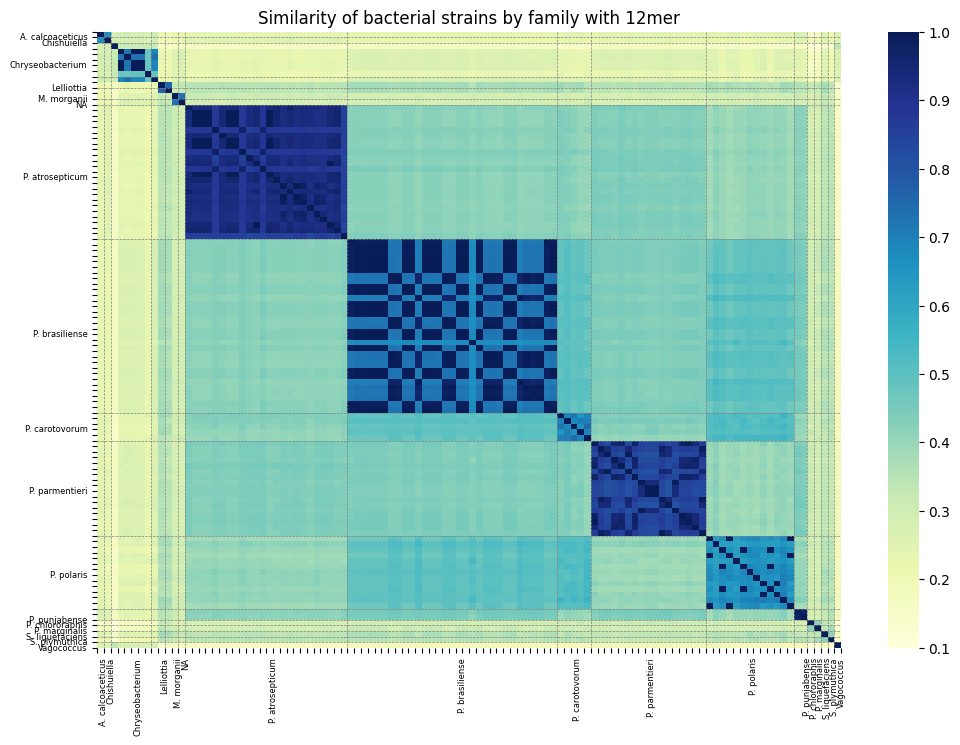

In [24]:
from collections import Counter
import matplotlib.pyplot as plt 
import seaborn as sns

def unique_axis_labels(labels):
    counts = Counter(labels)
    l_dict = {}
    for l_uniq in set(labels):
        for i, label in enumerate(labels):
            if l_uniq == label:

                l_dict[l_uniq] = i + round(counts[l_uniq]/2)
                break
    labels_out = ["" for _ in range(len(labels))] #filled with "-" to remove duplicates
    for key, value in l_dict.items():
        labels_out[value] = key
    return labels_out


def reformat_bact_names(bact_names : list):
    new_names = []
    for name in bact_names:
        name_split = name.split(" ")
        if len(name_split) > 1: #two names
            kingdom_abbrev = name.split(" ")[0][0].strip(" ")
            new_names.append(kingdom_abbrev+". "+name.split(" ")[1])
        else:
            new_names.append(name)
    return new_names

### Prepping dataframe (without species)
sim_bact_sorted_df.to_csv(data_prod_path+"sim_bact_sorted_df.csv")
sim_bact_sorted_data_df = sim_bact_sorted_df.drop(index="Species").drop(columns=["Species"])
#display(sim_bact_sorted_data_df)
sim_bact_sorted_data_df = sim_bact_sorted_data_df.astype(float) 

### Making unique labels
labels_abbrev = reformat_bact_names(sim_bact_sorted_df["Species"].values)
labels_unique = unique_axis_labels(labels_abbrev)

plt.figure(figsize=(12,8))
sns.heatmap(sim_bact_sorted_data_df, cmap="YlGnBu")

plt.xticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    rotation=90,
    fontsize=6
    )

plt.yticks(
    ticks=range(len(sim_bact_sorted_data_df.index)+1),
    labels=labels_unique,
    fontsize=6
    )

# Adding y lines for species 
y_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_y = [i for i in range(1, len(y_labels)) if y_labels[i] != y_labels[i-1]] # Find the indices where the species label changes
for idy in species_change_indices_y: # Plot horizontal lines at these indices
    plt.hlines(idy-1, xmin=0, xmax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

# Adding x lines for species 
x_labels = sim_bact_sorted_df["Species"].values # Get the species labels for the y-axis
species_change_indices_x = [i for i in range(1, len(x_labels)) if x_labels[i] != x_labels[i-1]] # Find the indices where the species label changes
for idx in species_change_indices_x: # Plot horizontal lines at these indices
    plt.vlines(idx-1, ymin=0, ymax=len(sim_bact_sorted_data_df.columns), colors='grey', linestyles='dashed', linewidth=0.5)

plt.title(f"Similarity of bacterial strains by family with {K}mer")

### Defining clusters of bacteria

In [42]:
cluster_mapping_bact = {
    0 : ["Pectobacterium atrosepticum"],
    1 : ["Pectobacterium brasiliense"],
    2 : ["Pectobacterium parmentieri"],
    3 : ["Pectobacterium polaris", "Pectobacterium carotovorum"],
    4 : ["Remaining species"]
}

In [43]:
set(sim_bact_sorted_df["Species"])

{'Acinetobacter calcoaceticus',
 'Chishuiella',
 'Chryseobacterium',
 'Lelliottia',
 'Morganella morganii',
 'NA',
 'Pectobacterium atrosepticum',
 'Pectobacterium brasiliense',
 'Pectobacterium carotovorum',
 'Pectobacterium parmentieri',
 'Pectobacterium polaris',
 'Pectobacterium punjabense',
 'Pseudomonas chlororaphis',
 'Pseudomonas marginalis',
 'Serratia liquefaciens',
 'Serratia plymuthica',
 'Vagococcus'}

/tmp/ipykernel_1304326/629292116.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


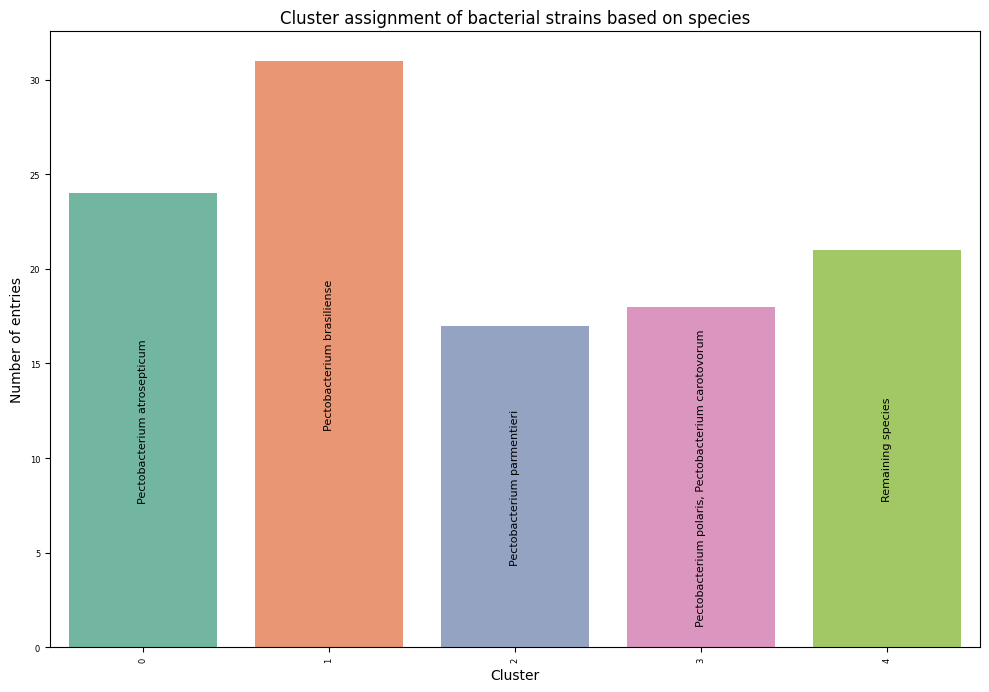

In [49]:
# Add a Cluster column based on Species values
species_to_cluster = {
    species: cluster
    for cluster, species_list in cluster_mapping_bact.items()
    for species in species_list
    if species != "Remaining species"
}

sim_bact_sorted_df["Cluster"] = (
    sim_bact_sorted_df["Species"]
    .map(species_to_cluster)
    .fillna(4)
    .astype(int)
)

plt.figure(figsize=(12, 8))

cluster_counts = sim_bact_sorted_df["Cluster"].value_counts().sort_index()
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")

cluster_names = {
    cluster: ("Remaining species" if cluster == 4 else ", ".join(species_list))
    for cluster, species_list in cluster_mapping_bact.items()
}

for bar, cluster in zip(ax.patches, cluster_counts.index):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        cluster_names.get(cluster, str(cluster)),
        ha="center",
        va="center",
        rotation=90,
        fontsize=8,
        color="black",
    )

plt.xlabel("Cluster")
plt.ylabel("Number of entries")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.title("Cluster assignment of bacterial strains based on species")
plt.show()

#### Saving bacteria clusters

In [61]:
bact_clusters_with_genus = sim_bact_sorted_df[["Cluster", "Species"]].copy()

# remove metadata row if present
bact_clusters_with_genus = bact_clusters_with_genus.loc[
    bact_clusters_with_genus.index != "Species"
]

bact_clusters_with_genus["genus"] = bact_clusters_with_genus["Species"].str.split().str[0]
bact_clusters_with_genus["strain_short"] = bact_clusters_with_genus.index
bact_clusters_with_genus.index = bact_clusters_with_genus.index + "_reoriented"
bact_clusters_with_genus = bact_clusters_with_genus[["strain_short", "Cluster", "Species", "genus"]]

display(bact_clusters_with_genus)
bact_clusters_with_genus.to_csv(data_prod_path+"bact_clusters_with_genus.csv", index=True)

,strain_short,Cluster,Species,genus
J53_21_reoriented,J53_21,4,Acinetobacter calcoaceticus,Acinetobacter
J14_21_reoriented,J14_21,4,Acinetobacter calcoaceticus,Acinetobacter
J105_22_reoriented,J105_22,4,Chishuiella,Chishuiella
J2264_1_22_KMC_reoriented,J2264_1_22_KMC,4,Chryseobacterium,Chryseobacterium
J50_21_reoriented,J50_21,4,Chryseobacterium,Chryseobacterium
...,...,...,...,...
J109_23_reoriented,J109_23,4,Pseudomonas chlororaphis,Pseudomonas
J101_22_reoriented,J101_22,4,Pseudomonas marginalis,Pseudomonas
J15_21_reoriented,J15_21,4,Serratia liquefaciens,Serratia
J4_21_reoriented,J4_21,4,Serratia plymuthica,Serratia


## Defining clusters based on similarity - Phage
Defining bacteria and phage cluster based on sequence (jaccard) similarity - only downsampled genomes

### Load minhash signatures and calculate jaccard similarity

In [62]:
import pandas as pd
import sourmash, os, sys
from paths import *
K = 12
n = 500
minhashes = []
print(f"Raw data path: {raw_data_path}\nData production path: {data_prod_path}")
sig_dir = data_prod_path+"SM_sketches/"+f"PhageMinhash_n{n}_k{K}/"
print("Number of signatures", len(os.listdir(sig_dir)))

"""
### Loading sigs - individually
for file in os.listdir(sig_dir):
    try:
        single_sig = sourmash.load_one_signature(sig_dir+file)
        print(single_sig)
    except: #catching wrongful load of signatures
        print(f"Failed to load {file}, now exiting")
        sys.exit(1)
    minhashes.append(single_sig)
"""

### Loading sigs - collectively
loaded_sigs = list(sourmash.load_file_as_signatures(sig_dir))
print(loaded_sigs[0], loaded_sigs[1])

Raw data path: /net/node07/home/projects/s215045/PredictPhagePPI/raw_data/
Data production path: /net/node07/home/projects/s215045/PredictPhagePPI/data_prod/
Number of signatures 23
Lelliottia_phage_Pantea Pectobacterium_phage_Magnum


In [63]:
from tqdm import tqdm
import numpy as np

num_sigs = len(loaded_sigs)
count_zero_jac = 0
count_nonzero_jac = 0
jac_matrix = np.zeros((num_sigs, num_sigs))

for i in tqdm(range(num_sigs), desc="Iterating through loaded sigs (Outer loop)", unit="sigs"):
    for j in range(num_sigs):
        jac = loaded_sigs[i].jaccard(loaded_sigs[j])
        if jac > 0:
            jac_matrix[i, j] = jac
            count_nonzero_jac += 1
        else:
            #no need to add at jac_matrix, as it is already filled with zeros
            count_zero_jac += 1

print(f"Jaccard sim above 0 vs at zero: {count_nonzero_jac}/{count_zero_jac}")

Iterating through loaded sigs (Outer loop): 100%|██████████| 23/23 [00:00<00:00, 1143.04sigs/s]

Jaccard sim above 0 vs at zero: 497/32


In [64]:
#print([l.minhash.hashes.keys() for l in loaded_sigs])

phage_names = []
for i in range(num_sigs):
    #print(str(loaded_sigs[i]), type(loaded_sigs[i]))
    phage_names.append(str(loaded_sigs[i]))

for name in phage_names:
    print(name, type(name))

Lelliottia_phage_Pantea <class 'str'>
Pectobacterium_phage_Magnum <class 'str'>
Pectobacterium_phage_Vims <class 'str'>
Serratia_phage_Echoes <class 'str'>
Serratia_phage_Galvinrad <class 'str'>
Serratia_phage_Uther <class 'str'>
Pectobacterium_phage_Mimer <class 'str'>
Pectobacterium_phage_Abuela <class 'str'>
Pectobacterium_phage_Koroua <class 'str'>
Pectobacterium_phage_Sabo <class 'str'>
Pectobacterium_phage_Taid <class 'str'>
Lelliottia_phage_Rap <class 'str'>
Pectobacterium_phage_Ymer <class 'str'>
Pectobacterium_phage_Amona <class 'str'>
Pectobacterium_phage_Poppous <class 'str'>
Lelliottia_phage_Zann <class 'str'>
Morganella_phage_Rip <class 'str'>
Morganella_phage_Rup <class 'str'>
Morganella_phage_Slaad <class 'str'>
Pectobacterium_phage_Crus <class 'str'>
Pectobacterium_phage_Gander <class 'str'>
Pectobacterium_phage_Guf <class 'str'>
Pectobacterium_phage_Hoejben <class 'str'>


#### Similarity plot ordered by family
Lookup ids in excel file

In [66]:
# hostrange_pdf = pd.read_excel(raw_data_path+"phagehost_KU/Hostrange_data_all_crisp_iso.xlsx", sheet_name="sum_hostrange", header=1)
# id_lookup_bact = hostrange_pdf.set_index("Seq ID")["Species"] #fasta seq IDs + bacteria species lookup
# print(id_lookup_bact)

sim_phage_df = pd.DataFrame(jac_matrix)
sim_phage_df.columns = phage_names
sim_phage_df.index = phage_names
display(sim_phage_df)

,Lelliottia_phage_Pantea,Pectobacterium_phage_Magnum,Pectobacterium_phage_Vims,Serratia_phage_Echoes,Serratia_phage_Galvinrad,Serratia_phage_Uther,Pectobacterium_phage_Mimer,Pectobacterium_phage_Abuela,Pectobacterium_phage_Koroua,Pectobacterium_phage_Sabo,...,Pectobacterium_phage_Amona,Pectobacterium_phage_Poppous,Lelliottia_phage_Zann,Morganella_phage_Rip,Morganella_phage_Rup,Morganella_phage_Slaad,Pectobacterium_phage_Crus,Pectobacterium_phage_Gander,Pectobacterium_phage_Guf,Pectobacterium_phage_Hoejben
Lelliottia_phage_Pantea,1.000,0.008,0.006,0.010,0.006,0.008,0.002,0.006,0.008,0.008,...,0.002,0.008,0.000,0.012,0.014,0.002,0.004,0.008,0.004,0.006
Pectobacterium_phage_Magnum,0.008,1.000,0.006,0.002,0.006,0.006,0.002,0.004,0.006,0.006,...,0.006,0.010,0.012,0.008,0.006,0.004,0.006,0.006,0.006,0.006
Pectobacterium_phage_Vims,0.006,0.006,1.000,0.006,0.004,0.002,0.002,0.004,0.004,0.004,...,0.008,0.010,0.004,0.002,0.006,0.004,0.002,0.002,0.002,0.004
Serratia_phage_Echoes,0.010,0.002,0.006,1.000,0.004,0.004,0.000,0.002,0.002,0.000,...,0.002,0.002,0.004,0.018,0.026,0.002,0.002,0.004,0.002,0.002
Serratia_phage_Galvinrad,0.006,0.006,0.004,0.004,1.000,0.002,0.002,0.006,0.008,0.008,...,0.002,0.004,0.006,0.002,0.004,0.004,0.002,0.006,0.004,0.002
Serratia_phage_Uther,0.008,0.006,0.002,0.004,0.002,1.000,0.002,0.002,0.004,0.004,...,0.006,0.006,0.008,0.002,0.004,0.006,0.002,0.004,0.002,0.002
Pectobacterium_phage_Mimer,0.002,0.002,0.002,0.000,0.002,0.002,1.000,0.002,0.002,0.002,...,0.002,0.004,0.004,0.000,0.002,0.004,0.000,0.000,0.000,0.000
Pectobacterium_phage_Abuela,0.006,0.004,0.004,0.002,0.006,0.002,0.002,1.000,0.660,0.646,...,0.502,0.258,0.010,0.004,0.002,0.006,0.004,0.006,0.002,0.004
Pectobacterium_phage_Koroua,0.008,0.006,0.004,0.002,0.008,0.004,0.002,0.660,1.000,0.578,...,0.486,0.228,0.012,0.004,0.002,0.004,0.004,0.006,0.002,0.004
Pectobacterium_phage_Sabo,0.008,0.006,0.004,0.000,0.008,0.004,0.002,0.646,0.578,1.000,...,0.532,0.296,0.012,0.004,0.002,0.006,0.002,0.006,0.002,0.002


### Defining clusters of Phages

In [67]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert Similarity to Distance
# Assuming 'df' is your dataframe from the screenshot
# distance = 1 - similarity
dist_matrix = 1 - sim_phage_df

# 2. Apply Agglomerative Clustering
# We use 'precomputed' affinity because we are providing a distance matrix
cluster_model = AgglomerativeClustering(
    n_clusters=5, 
    metric='precomputed', 
    linkage='average' # 'average' or 'complete' work well for genomic clusters
)

clusters = cluster_model.fit_predict(dist_matrix)

# 3. Map clusters back to your sequence names
results = pd.DataFrame({
    'Sequence': sim_phage_df.index,
    'Cluster': clusters
}).sort_values(by='Cluster')

print(results)

                        Sequence  Cluster
1    Pectobacterium_phage_Magnum        0
2      Pectobacterium_phage_Vims        0
7    Pectobacterium_phage_Abuela        0
4       Serratia_phage_Galvinrad        0
11          Lelliottia_phage_Rap        0
10     Pectobacterium_phage_Taid        0
9      Pectobacterium_phage_Sabo        0
8    Pectobacterium_phage_Koroua        0
12     Pectobacterium_phage_Ymer        0
13    Pectobacterium_phage_Amona        0
14  Pectobacterium_phage_Poppous        0
15         Lelliottia_phage_Zann        0
5           Serratia_phage_Uther        1
18        Morganella_phage_Slaad        1
19     Pectobacterium_phage_Crus        2
21      Pectobacterium_phage_Guf        2
22  Pectobacterium_phage_Hoejben        2
20   Pectobacterium_phage_Gander        2
6     Pectobacterium_phage_Mimer        3
0        Lelliottia_phage_Pantea        4
3          Serratia_phage_Echoes        4
17          Morganella_phage_Rup        4
16          Morganella_phage_Rip  

In [72]:
import pandas as pd
import numpy as np

# 1. Calculate the distance matrix
dist_matrix = 1 - sim_phage_df

# 2. Get a 1D representation for sorting
# We calculate the mean distance of each sequence to all others.
# Lower mean distance = more "central" sequences.
# Higher mean distance = more "outlier" sequences.
sorting_metric = dist_matrix.mean(axis=1)

# 3. Sort the sequences based on this metric
sorted_sequences = sorting_metric.sort_values().index

# 4. Divide into 5 equal groups
# Using numpy.array_split to handle cases where the total count 
# isn't perfectly divisible by 5.
groups = np.array_split(sorted_sequences, 5)

# 5. Map back to a clean DataFrame
cluster_map = {}
for i, group in enumerate(groups):
    for seq in group:
        cluster_map[seq] = {i}

results = pd.DataFrame.from_dict(cluster_map, orient='index', columns=['Cluster'])

print(f"Total sequences: {len(results)}")
print(results['Cluster'].value_counts()) # Verify equal sizes
print(results)

Total sequences: 23
Cluster
0    5
1    5
2    5
3    4
4    4
Name: count, dtype: int64
                              Cluster
Pectobacterium_phage_Abuela         0
Pectobacterium_phage_Ymer           0
Pectobacterium_phage_Koroua         0
Pectobacterium_phage_Sabo           0
Pectobacterium_phage_Amona          0
Pectobacterium_phage_Poppous        1
Pectobacterium_phage_Guf            1
Pectobacterium_phage_Hoejben        1
Pectobacterium_phage_Taid           1
Pectobacterium_phage_Crus           1
Pectobacterium_phage_Gander         2
Morganella_phage_Rup                2
Morganella_phage_Rip                2
Lelliottia_phage_Zann               2
Lelliottia_phage_Pantea             2
Pectobacterium_phage_Magnum         3
Serratia_phage_Echoes               3
Morganella_phage_Slaad              3
Serratia_phage_Galvinrad            3
Pectobacterium_phage_Vims           4
Serratia_phage_Uther                4
Lelliottia_phage_Rap                4
Pectobacterium_phage_Mimer          4

#### Saving bacteria clusters

In [75]:
phage_clusters = results.copy()

# remove metadata row if present
phage_clusters = phage_clusters.loc[
    phage_clusters.index != "Species"
]

display(phage_clusters)
phage_clusters.to_csv(data_prod_path+"phage_clusters.csv", index=True)

,Cluster
Pectobacterium_phage_Abuela,0
Pectobacterium_phage_Ymer,0
Pectobacterium_phage_Koroua,0
Pectobacterium_phage_Sabo,0
Pectobacterium_phage_Amona,0
Pectobacterium_phage_Poppous,1
Pectobacterium_phage_Guf,1
Pectobacterium_phage_Hoejben,1
Pectobacterium_phage_Taid,1
Pectobacterium_phage_Crus,1
